# Aim 1 — Middle-Layer Logit Lens + Min/Mean/Max Metrics

Offline HuggingFace run (use a GPU node).

Package: `logit_lens_aim1_AND`

Same pipeline as `output_logit_aim1_AND`, but Top-K distributions come from a
**logit lens at a chosen transformer layer** (default = middle layer).

For each corpus pair `(word_a, word_b)`:
1. Build typicality prompts `P_A`, `P_B`, `P_AB`
2. Extract Top-K softmax via logit lens at `layer_index` (final token)
3. Compare pointwise **min / mean / max** of `(p_A, p_B)` to `p_AB`

| Module | Role |
|---|---|
| `config.py` | model id, Top-K, layer, paths |
| `prompts.py` | typicality templates |
| `model_io.py` | load model + middle-layer logit lens |
| `metrics.py` | min / mean / max vs `p_AB` |
| `rank_diff.py` | rank-aligned `|agg − p_AB|` curves |
| `experiment.py` | corpus loop, resume, save |

In [1]:
import os, socket, torch
print("hostname:", socket.gethostname())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU visible to this kernel")

hostname: gpun203
CUDA_VISIBLE_DEVICES: None
cuda available: True
GPU: NVIDIA A100 80GB PCIe


## 0. Setup (once on the GPU node)

```bash
conda activate ect   # or your GPU env
pip install -r requirements.txt
```

Default model: `Qwen/Qwen3.5-2B` (override with `LOGIT_LENS_MODEL`).
Default layer: middle (`n_layers // 2`); override with `LAYER_INDEX` below or `LOGIT_LENS_LAYER`.

In [2]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import torch

_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "logit_lens_aim1_AND",
    _cwd / "src" / "logit_lens_aim1_AND",
    Path("/home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND"),
]
PKG_DIR = next((p for p in _candidates if (p / "experiment.py").exists()), _cwd)
SRC_DIR = PKG_DIR.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import logit_lens_aim1_AND.config as _cfg
import logit_lens_aim1_AND.prompts as _prompts
import logit_lens_aim1_AND.model_io as _mio
import logit_lens_aim1_AND.metrics as _metrics
import logit_lens_aim1_AND.experiment as _exp
import logit_lens_aim1_AND as _pkg

for m in (_cfg, _prompts, _mio, _metrics, _exp, _pkg):
    importlib.reload(m)

from logit_lens_aim1_AND import run_experiment
from logit_lens_aim1_AND.config import (
    DEFAULT_CORPUS_JSONL,
    DEFAULT_OUTPUT_DIR,
    LAYER_INDEX,
    MODEL_ID,
    TOP_K,
    distributions_jsonl_for_layer,
    metrics_csv_for_layer,
)
from logit_lens_aim1_AND.model_io import load_model_and_tokenizer, num_transformer_layers, resolve_layer_index

# ---------------------------------------------------------------------------
# Layer selection (edit here)
#   None  → middle layer = n_layers // 2  (default)
#   int   → transformer block index in [0, n_layers-1]
# ---------------------------------------------------------------------------
LAYER_INDEX_OVERRIDE = 10  # or set e.g. 14

print("PKG_DIR:", PKG_DIR)
print("MODEL_ID:", MODEL_ID)
print("TOP_K:", TOP_K)
print("LAYER_INDEX_OVERRIDE:", LAYER_INDEX_OVERRIDE, "(None → middle)")
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("corpus exists:", DEFAULT_CORPUS_JSONL.exists(), DEFAULT_CORPUS_JSONL)

/home/WUR/lu087/miniconda3/envs/ect/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PKG_DIR: /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND
MODEL_ID: Qwen/Qwen3.5-2B
TOP_K: 4096
LAYER_INDEX_OVERRIDE: 10 (None → middle)
cuda available: True
GPU: NVIDIA A100 80GB PCIe
corpus exists: True /home/WUR/lu087/Github/ect/src/vocabulary_gen_aim1_AND/output/orthogonality_spectrum_corpus.jsonl


## 1. Smoke test (a few pairs)

Run this first on the GPU node to verify model download + logit-lens forward pass.
Writes under `output/layer_{L}/smoke_*`.

In [ ]:
smoke = run_experiment(
    corpus_path=DEFAULT_CORPUS_JSONL,
    model_id=MODEL_ID,
    top_k=TOP_K,
    layer_index=LAYER_INDEX_OVERRIDE,  # None → middle layer
    max_pairs=2,
    categories=[1],
    resume=False,
    save_every=1,
    distributions_jsonl=DEFAULT_OUTPUT_DIR / "smoke_distributions.jsonl",
    metrics_jsonl=DEFAULT_OUTPUT_DIR / "smoke_metrics.jsonl",
    metrics_csv=DEFAULT_OUTPUT_DIR / "smoke_metrics.csv",
    verbose=True,
)
smoke

## 2. Full experiment

Writes (per resolved layer `L`):
- `output/layer_{L}/extracted_distributions_top4096.jsonl`
- `output/layer_{L}/composition_metrics_min_mean_max.jsonl` / `.csv`

`resume=True` skips pairs already in that layer's metrics file.

In [3]:
# Tunables
CATEGORIES = None          # e.g. [1, 2, 3, 4, 5] or None for all
MAX_PAIRS = None           # set an int to cap; None = full corpus
# LAYER_INDEX_OVERRIDE is set in the setup cell (None = middle layer)

result = run_experiment(
    corpus_path=DEFAULT_CORPUS_JSONL,
    model_id=MODEL_ID,
    top_k=TOP_K,
    layer_index=LAYER_INDEX_OVERRIDE,
    device="auto",
    dtype_name="bfloat16",
    max_pairs=MAX_PAIRS,
    categories=CATEGORIES,
    resume=True,
    save_every=25,
    verbose=True,
)
result

model_id=Qwen/Qwen3.5-2B
corpus=/home/WUR/lu087/Github/ect/src/vocabulary_gen_aim1_AND/output/orthogonality_spectrum_corpus.jsonl (n=3885)
top_k=4096 device=auto dtype=bfloat16
layer_index request=10 (None → middle)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:00<00:00, 9453.62it/s]


loaded on cuda, vocab_size=248077
n_layers=24 → using layer_index=10
apply_final_norm=True
distributions → /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/extracted_distributions_top4096.jsonl
todo=3885 done=0
[1/3885] L=10 cat=1 'Transitive Verb' ∧ 'Verb' | min_cos=0.0847 mean_cos=0.0950 max_cos=0.1000
[10/3885] L=10 cat=1 'Superlative Adjective' ∧ 'Adjective' | min_cos=0.1746 mean_cos=0.1828 max_cos=0.1882
[20/3885] L=10 cat=1 'Definite Article' ∧ 'Determiner' | min_cos=0.6874 mean_cos=0.6723 max_cos=0.6286
[30/3885] L=10 cat=1 'Relative Clause' ∧ 'Clause' | min_cos=0.4046 mean_cos=0.4292 max_cos=0.4325
[40/3885] L=10 cat=1 'Exclamatory Sentence' ∧ 'Sentence' | min_cos=0.1577 mean_cos=0.1478 max_cos=0.1439
[50/3885] L=10 cat=1 'Active Voice' ∧ 'Voice' | min_cos=0.1114 mean_cos=0.1193 max_cos=0.1208
[60/3885] L=10 cat=1 'Sleet' ∧ 'Precipitation' | min_cos=0.4467 mean_cos=0.5067 max_cos=0.5046
[70/3885] L=10 cat=1 'Cold Front' ∧ 'Front' | min_cos=0.4333 mean_cos=0.41

{'n_total': 3885,
 'n_done_before': 0,
 'n_new': 3885,
 'layer_index': 10,
 'n_layers': 24,
 'distributions_jsonl': '/home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/extracted_distributions_top4096.jsonl',
 'metrics_csv': '/home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/composition_metrics_min_mean_max.csv'}

## 3. Quick look at metrics

In [4]:
import pandas as pd

# Prefer the layer from the last full/smoke run; else set manually.
if "result" in globals() and isinstance(result, dict) and "layer_index" in result:
    layer_for_metrics = int(result["layer_index"])
elif "smoke" in globals() and isinstance(smoke, dict) and "layer_index" in smoke:
    layer_for_metrics = int(smoke["layer_index"])
else:
    layer_for_metrics = None  # e.g. set to 14

if layer_for_metrics is None:
    raise RuntimeError("Set layer_for_metrics to the layer you ran, or re-run an experiment cell.")

metrics_csv = metrics_csv_for_layer(layer_for_metrics, DEFAULT_OUTPUT_DIR)
print("Reading", metrics_csv)
df = pd.read_csv(metrics_csv)
cols = [
    "category_id",
    "layer_index",
    "word_a",
    "word_b",
    "min_cosine_to_ab",
    "mean_cosine_to_ab",
    "max_cosine_to_ab",
    "min_mass",
    "mean_mass",
    "max_mass",
]
display(df[[c for c in cols if c in df.columns]].head(10))
display(df.groupby("category_id")[["min_cosine_to_ab", "mean_cosine_to_ab", "max_cosine_to_ab"]].mean())

Reading /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/composition_metrics_min_mean_max.csv


,category_id,layer_index,word_a,word_b,min_cosine_to_ab,mean_cosine_to_ab,max_cosine_to_ab,min_mass,mean_mass,max_mass
0,1,10,Transitive Verb,Verb,0.084670,0.094964,0.100038,0.136825,0.419721,0.702617
1,1,10,Intransitive Verb,Verb,0.095975,0.105983,0.110472,0.124554,0.417767,0.710980
2,1,10,Auxiliary Verb,Verb,0.323363,0.335773,0.329515,0.163805,0.428062,0.692318
3,1,10,Irregular Noun,Noun,0.137335,0.116343,0.109341,0.168946,0.386593,0.604241
4,1,10,Countable Noun,Noun,0.128246,0.161767,0.166368,0.170855,0.387576,0.604298
5,1,10,Mass Noun,Noun,0.130412,0.112114,0.104444,0.159803,0.422772,0.685741
6,1,10,Proper Noun,Noun,0.206393,0.190184,0.179859,0.166644,0.387197,0.607749
7,1,10,Common Noun,Noun,0.134403,0.148932,0.147966,0.174318,0.377907,0.581496
8,1,10,Comparative Adjective,Adjective,0.379685,0.392873,0.400279,0.206442,0.419064,0.631687
9,1,10,Superlative Adjective,Adjective,0.174557,0.182842,0.188248,0.202334,0.413472,0.624610


,min_cosine_to_ab,mean_cosine_to_ab,max_cosine_to_ab
category_id,,,
1,0.331408,0.343494,0.339188
2,0.291000,0.297063,0.290691
3,0.300732,0.306430,0.298530
4,0.213562,0.215820,0.208850
5,0.285280,0.288081,0.285202


## 4. Rank-aligned difference curves (min / mean / max vs p_AB)

Identical to the output-logit analysis:
1. Sort ground-truth `p_AB` Top-4096 by probability (high → low)
2. Evaluate pointwise **min / mean / max** of `(p_A, p_B)` on those tokens
3. Absolute difference `|agg − p_AB|` at each rank

Per category: mean curve + 5%/95% quantile ribbon.

In [5]:
import importlib

import logit_lens_aim1_AND.rank_diff as _rank_diff

importlib.reload(_rank_diff)
from logit_lens_aim1_AND.rank_diff import (
    compute_rank_diff_summary,
    load_rank_diff_summary,
    plot_category_rank_diffs,
    save_rank_diff_summary,
)

if "result" in globals() and isinstance(result, dict) and "layer_index" in result:
    layer_for_plots = int(result["layer_index"])
elif "layer_for_metrics" in globals() and layer_for_metrics is not None:
    layer_for_plots = int(layer_for_metrics)
else:
    raise RuntimeError("Set layer_for_plots / run an experiment cell first.")

layer_dir = DEFAULT_OUTPUT_DIR / f"layer_{layer_for_plots}"
DIST_JSONL = distributions_jsonl_for_layer(layer_for_plots, DEFAULT_OUTPUT_DIR)
RANK_DIFF_NPZ = layer_dir / "rank_diff_summary_q05_q95.npz"
RANK_DIFF_FIG_DIR = layer_dir / "figures_rank_diff"

RECOMPUTE_RANK_DIFFS = not RANK_DIFF_NPZ.exists()

if RECOMPUTE_RANK_DIFFS:
    print("Computing rank-aligned diffs from", DIST_JSONL)
    rank_summary = compute_rank_diff_summary(DIST_JSONL, q_low=0.05, q_high=0.95)
    save_rank_diff_summary(rank_summary, RANK_DIFF_NPZ)
    print("Wrote", RANK_DIFF_NPZ)
else:
    print("Loading cached summary", RANK_DIFF_NPZ)
    rank_summary = load_rank_diff_summary(RANK_DIFF_NPZ)

for cid, blob in sorted(rank_summary.items()):
    print(f"cat={cid} n={blob['n_pairs']} K={blob['top_k']} | {blob['category_name']}")

Computing rank-aligned diffs from /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/extracted_distributions_top4096.jsonl
Wrote /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/rank_diff_summary_q05_q95.npz
cat=1 n=799 K=4096 | Redundant / Strict Entailment
cat=2 n=795 K=4096 | Typical Composition
cat=3 n=750 K=4096 | Uncommon / Orthogonal
cat=4 n=795 K=4096 | Surreal / Out-of-Distribution
cat=5 n=746 K=4096 | Mutually Exclusive / Paradoxical


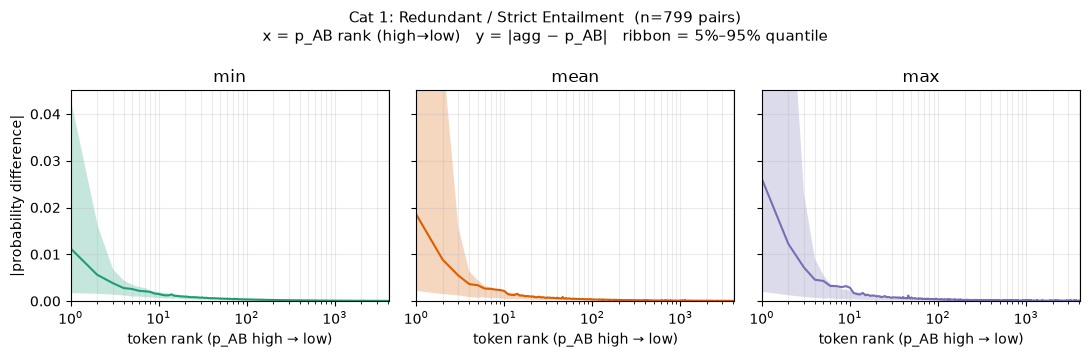

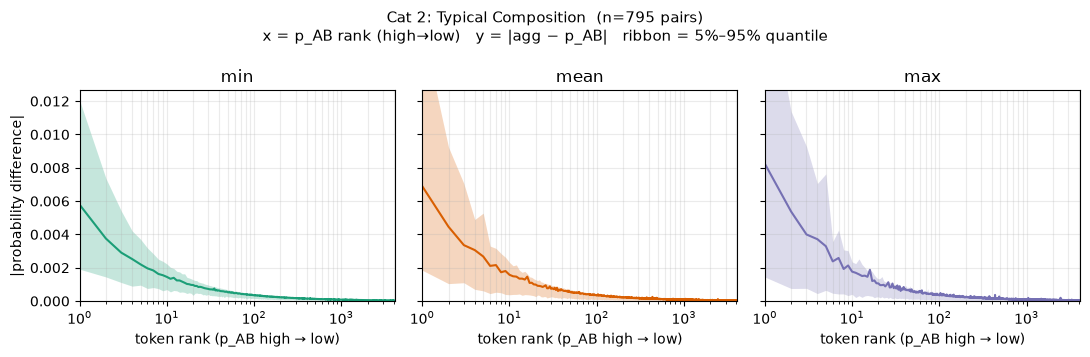

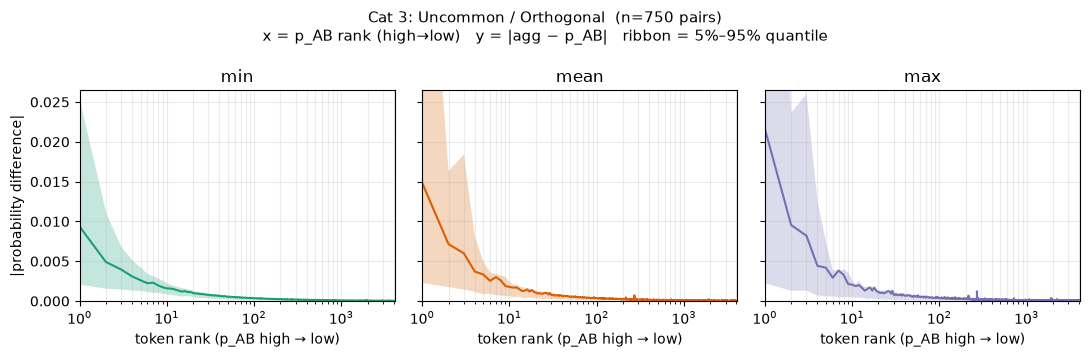

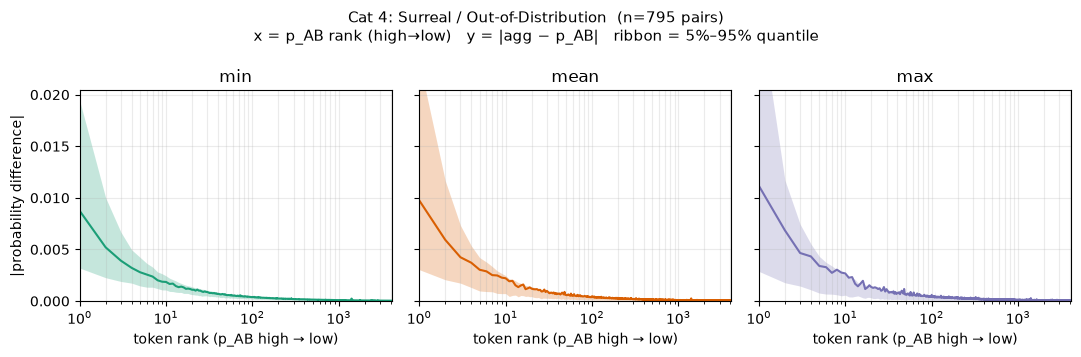

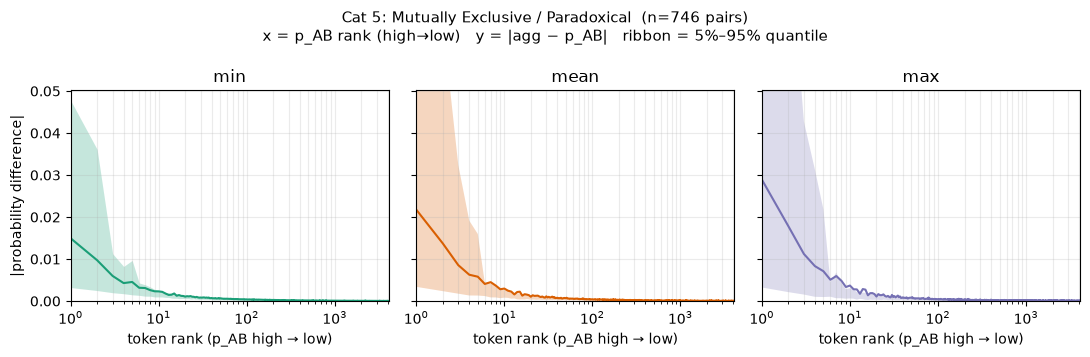

Saved figures:
  /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/figures_rank_diff/rank_diff_cat1.png
  /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/figures_rank_diff/rank_diff_cat2.png
  /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/figures_rank_diff/rank_diff_cat3.png
  /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/figures_rank_diff/rank_diff_cat4.png
  /home/WUR/lu087/Github/ect/src/logit_lens_aim1_AND/output/layer_10/figures_rank_diff/rank_diff_cat5.png


In [6]:
paths = plot_category_rank_diffs(
    rank_summary,
    out_dir=RANK_DIFF_FIG_DIR,
    show=True,
    log_x=True,
)
print("Saved figures:")
for p in paths:
    print(" ", p)